### Week 6 — Feature Engineering
#### Task
- Create 3 new features
- Retrain model
- Compare results before and after
#### Deliverables
- Feature explanation
- Performance improvement analysis

### 1.Importing Libraries

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score

### 2.Load The Dataset

In [22]:
df_raw = pd.read_csv('Titanic.csv')
print("Shape:", df_raw.shape)
df_raw.head()

Shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


#### 3 Baseline Preprocessing (No New Features)

In [23]:
df_base = df_raw.copy()

# Filling missing values with median/mode
df_base['Age'] = df_base['Age'].fillna(df_base['Age'].median())
df_base['Embarked'] = df_base['Embarked'].fillna(df_base['Embarked'].mode()[0])

# Encode categorical variables
le_base = LabelEncoder()
df_base['Sex'] = le_base.fit_transform(df_base['Sex'])
df_base = pd.get_dummies(df_base, columns=['Embarked'], drop_first=True)

# Drop columns not used in model training
df_base = df_base.drop(columns=['Name', 'Cabin', 'Ticket', 'PassengerId'])
df_base.head()


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,0,3,1,22.0,1,0,7.2500,False,True
1,1,1,0,38.0,1,0,71.2833,False,False
2,1,3,0,26.0,0,0,7.9250,False,True
3,1,1,0,35.0,1,0,53.1000,False,True
4,0,3,1,35.0,0,0,8.0500,False,True


### 4.Split the data

In [24]:
X_base = df_base.drop('Survived', axis=1)
y_base = df_base['Survived']

X_base_train, X_base_test, y_base_train, y_base_test = train_test_split(
    X_base, y_base, test_size=0.2, random_state=42, stratify=y_base
)

scaler_base = StandardScaler()
X_base_train_scaled = scaler_base.fit_transform(X_base_train)
X_base_test_scaled = scaler_base.transform(X_base_test)  # transform only, not fit_transform

print('Train size:', X_base_train.shape, 'Test size:', X_base_test.shape)


Train size: (712, 8) Test size: (179, 8)


### Model 1: Random Forest

In [25]:
# Random Forest (baseline)
rf_base = RandomForestClassifier(n_estimators=200, random_state=42)
rf_base.fit(X_base_train, y_base_train)
rf_base_pred = rf_base.predict(X_base_test)

rf_base_result = {
    'Accuracy': accuracy_score(y_base_test, rf_base_pred),
    'Precision': precision_score(y_base_test, rf_base_pred),
    'Recall': recall_score(y_base_test, rf_base_pred)
}


### Model 2: SVM

In [26]:
# SVM (baseline)
svm_base = SVC(kernel='rbf', random_state=42)
svm_base.fit(X_base_train_scaled, y_base_train)
svm_base_pred = svm_base.predict(X_base_test_scaled)

svm_base_result = {
    'Accuracy': accuracy_score(y_base_test, svm_base_pred),
    'Precision': precision_score(y_base_test, svm_base_pred),
    'Recall': recall_score(y_base_test, svm_base_pred)
}


### Model 3: KNN

In [27]:
# KNN (baseline)
knn_base = KNeighborsClassifier(n_neighbors=5)
knn_base.fit(X_base_train_scaled, y_base_train)
knn_base_pred = knn_base.predict(X_base_test_scaled)

knn_base_result = {
    'Accuracy': accuracy_score(y_base_test, knn_base_pred),
    'Precision': precision_score(y_base_test, knn_base_pred),
    'Recall': recall_score(y_base_test, knn_base_pred)
}


### Comparison of Each Model

In [28]:
before_df = pd.DataFrame({
    'Random Forest': rf_base_result,
    'SVM': svm_base_result,
    'KNN': knn_base_result
}).T.round(2)

print('BEFORE Feature Engineering')
before_df


BEFORE Feature Engineering


,Accuracy,Precision,Recall
Random Forest,0.82,0.79,0.71
SVM,0.81,0.84,0.62
KNN,0.82,0.80,0.70


### 3.Creating 3 New Features

In [29]:
df_new = df_raw.copy()

# Feature 1: Family Size
df_new['FamilySize'] = df_new['SibSp'] + df_new['Parch'] + 1

# Feature 2: Is Alone
df_new['IsAlone'] = (df_new['FamilySize'] == 1).astype(int)

# Feature 3: Title
df_new['Title'] = df_new['Name'].str.extract(' ([A-Za-z]+)\\.', expand=False)
df_new['Title'] = df_new['Title'].replace(
    ['Lady', 'Countess', 'Capt', 'Col', 'Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'],
    'Rare'
)
df_new['Title'] = df_new['Title'].replace({'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs'})
df_new[['Name', 'FamilySize', 'IsAlone', 'Title']].head()


,Name,FamilySize,IsAlone,Title
0,"Braund, Mr. Owen Harris",2,0,Mr
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",2,0,Mrs
2,"Heikkinen, Miss. Laina",1,1,Miss
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",2,0,Mrs
4,"Allen, Mr. William Henry",1,1,Mr


### 4.Data Preprocessing

In [30]:
# Filling missing values with median/mode
df_new['Age'] = df_new['Age'].fillna(df_new['Age'].median())
df_new['Embarked'] = df_new['Embarked'].fillna(df_new['Embarked'].mode()[0])

# Encode categorical variables
le_new = LabelEncoder()
df_new['Sex'] = le_new.fit_transform(df_new['Sex'])
df_new['Title'] = le_new.fit_transform(df_new['Title'])

df_new = pd.get_dummies(df_new, columns=['Embarked'], drop_first=True)

# Drop columns not used in model training
df_new = df_new.drop(columns=['Name', 'Cabin', 'Ticket', 'PassengerId'])
df_new.head()


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,FamilySize,IsAlone,Title,Embarked_Q,Embarked_S
0,0,3,1,22.0,1,0,7.2500,2,0,2,False,True
1,1,1,0,38.0,1,0,71.2833,2,0,3,False,False
2,1,3,0,26.0,0,0,7.9250,1,1,1,False,True
3,1,1,0,35.0,1,0,53.1000,2,0,3,False,True
4,0,3,1,35.0,0,0,8.0500,1,1,2,False,True


### 5.Split the Data Feature And Target

In [31]:
X2 = df_new.drop('Survived', axis=1)
y2 = df_new['Survived']

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42, stratify=y2
)

scaler2 = StandardScaler()
X2_train_scaled = scaler2.fit_transform(X2_train)
X2_test_scaled = scaler2.transform(X2_test)  # fixed: transform only, not fit_transform

print('Train size:', X2_train.shape, 'Test size:', X2_test.shape)


Train size: (712, 11) Test size: (179, 11)


### Model 1: Random Forest

In [32]:
Rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
Rf_model.fit(X2_train, y2_train)
Rf_pred = Rf_model.predict(X2_test)

Rf_result = {
    'Accuracy': accuracy_score(y2_test, Rf_pred),
    'Precision': precision_score(y2_test, Rf_pred),
    'Recall': recall_score(y2_test, Rf_pred)
}


### Model2: SVM(Support Vector Machine)

In [33]:
svm = SVC(kernel='rbf', random_state=42)
svm.fit(X2_train_scaled, y2_train)
svm_pred = svm.predict(X2_test_scaled)

Svm_result = {
    'Accuracy': accuracy_score(y2_test, svm_pred),
    'Precision': precision_score(y2_test, svm_pred),
    'Recall': recall_score(y2_test, svm_pred)
}


### Model 3: KNN(K-Nearest Neighbour)

In [34]:
Knn = KNeighborsClassifier(n_neighbors=5)
Knn.fit(X2_train_scaled, y2_train)
knn_pred = Knn.predict(X2_test_scaled)

Knn_result = {
    'Accuracy': accuracy_score(y2_test, knn_pred),
    'Precision': precision_score(y2_test, knn_pred),
    'Recall': recall_score(y2_test, knn_pred)
}


### Comparison of Each Model

In [35]:
after_df = pd.DataFrame({
    'Random Forest': Rf_result,
    'SVM': Svm_result,
    'KNN': Knn_result
}).T.round(2)

print('AFTER Feature Engineering')
after_df


AFTER Feature Engineering


,Accuracy,Precision,Recall
Random Forest,0.83,0.79,0.77
SVM,0.84,0.84,0.74
KNN,0.82,0.79,0.72


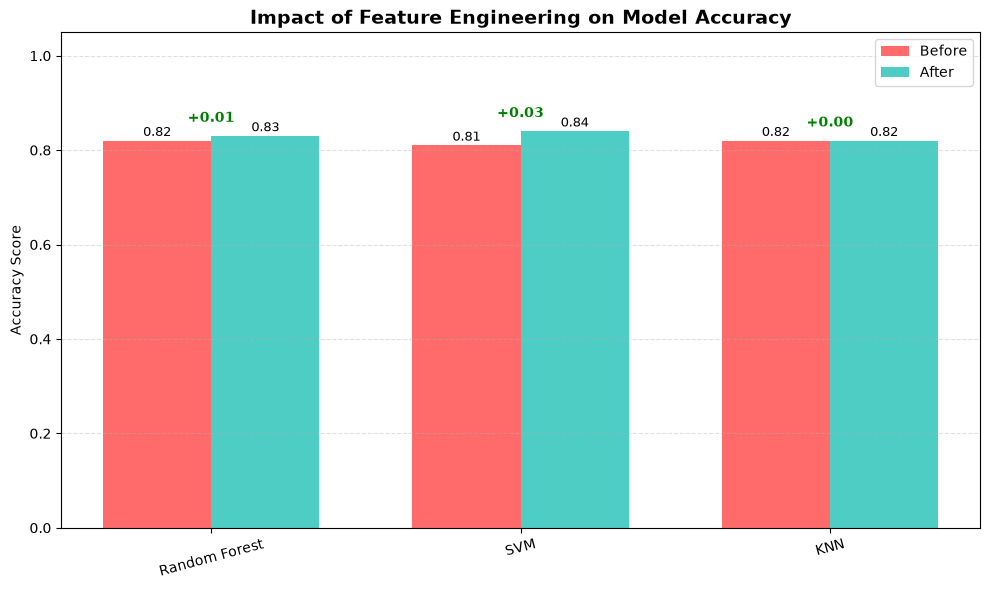

In [38]:
import numpy as np
import matplotlib.pyplot as plt
x = np.arange(len(before_df.index))
width = 0.35
fig, ax = plt.subplots(figsize=(10, 6))
before_bars = ax.bar(
    x - width/2,
    before_df['Accuracy'],
    width,
    label='Before',
    color='#ff6b6b'
    )
after_bars = ax.bar(
    x + width/2,
    after_df['Accuracy'],
    width,
    label='After',
    color='#4ecdc4'
)
# Add values and improvement annotations
for i, (b, a) in enumerate(zip(before_df['Accuracy'], after_df['Accuracy'])):
    ax.text(i - width/2, b + 0.01, f'{b:.2f}',
            ha='center', fontsize=9)
    ax.text(i + width/2, a + 0.01, f'{a:.2f}',
            ha='center', fontsize=9)
    diff = a - b
    ax.annotate(
        f'+{diff:.2f}',
        xy=(i, max(b, a) + 0.03),
        ha='center',
        fontsize=10,
        fontweight='bold',
        color='green'
)
ax.set_xticks(x)
ax.set_xticklabels(before_df.index, rotation=15)
ax.set_ylabel('Accuracy Score')

ax.set_title('Impact of Feature Engineering on Model Accuracy', fontsize=14, fontweight='bold')
ax.set_ylim(0, 1.05)

ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.legend()
plt.tight_layout()
plt.show()


### Performance Improvement Analysis

- **Random Forest:**: Accuracy increased from 0.82 to 0.83 (+0.01), and Recall improved from 0.71 to 0.77 (+0.06). The new features (FamilySize, IsAlone, and Title) helped the model identify survivors better.

- **SVM:** Accuracy increased from 0.81 to 0.84 (+0.03), and Recall improved from 0.62 to 0.74 (+0.12). The new features provided useful information, especially Title, which helped the model make better predictions.

- **KNN:** Accuracy remained 0.82 (no change), while Recall increased slightly from 0.70 to 0.72 (+0.02). The new features had only a small positive impact on the model.

**Overall: SVM** benefited the most from feature engineering, showing the highest improvement in both Accuracy and Recall. Random Forest also improved, especially in Recall. KNN showed only a slight improvement. Overall, the added features, particularly Title, were useful and improved model performance.